In [1]:
import kagglehub


path = kagglehub.dataset_download("mahmudulhasantasin/tnbc-nuclei-segmentation-original-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tnbc-nuclei-segmentation-original-dataset


In [2]:
import os, re, random, numpy as np, torch, cv2
from PIL import Image
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import functional as TF
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2

seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark=True
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
img_size=512
bs=4

train_transform = A.Compose([
    A.Resize(height=img_size, width=img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent={"x": 0.05, "y": 0.05}, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.ElasticTransform(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

val_transform = A.Compose([
    A.Resize(height=img_size, width=img_size),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

test_transform = A.Compose([
    A.Resize(height=img_size, width=img_size),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

In [3]:
import os
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from torchvision.transforms import functional as TF
from sklearn.model_selection import KFold, train_test_split
from scipy.io import loadmat
import albumentations as A
from albumentations.pytorch import ToTensorV2

batch_size = bs if 'bs' in globals() else 4

BASE = Path("/kaggle/input/tnbc-nuclei-segmentation-original-dataset/TNBC_NucleiSegmentation")
print("DATA_ROOT:", BASE)


def load_label_arr(path):
    if str(path).lower().endswith(".mat"):
        m = loadmat(path)
        for k in ("type_map","type","label","gt"):
            if k in m:
                a = np.asarray(m[k]).squeeze().astype(np.int32)
                return a
        for k in ("inst_map","inst"):
            if k in m:
                inst = np.asarray(m[k]).squeeze().astype(np.int32)
                return (inst > 0).astype(np.int32)
        raise ValueError(f"No usable keys in {path}")
    else:
        img = Image.open(path).convert("L")
        arr = np.array(img)
        arr = (arr > 0).astype(np.int32)
        return arr

        
def gather_tnbc_pairs(root_path):
    pairs = []
    for i in range(1, 12):
        slide_name = f"Slide_{i:02d}"
        gt_name = f"GT_{i:02d}"
        
        slide_dir = root_path / slide_name
        gt_dir = root_path / gt_name

        if not slide_dir.exists() or not gt_dir.exists():
            continue

        images = sorted([f for f in os.listdir(slide_dir) if f.lower().endswith('.png')])

        for img_name in images:
            img_path = slide_dir / img_name
            lbl_path = gt_dir / img_name

            if lbl_path.exists():
                pairs.append((str(img_path), str(lbl_path)))
            else:
                print(f"Warning: Label not found for {img_name} in {gt_dir}")
                
    return pairs


def unwrap_dataset(ds):
    while isinstance(ds, Subset):
        ds = ds.dataset
    return ds


class TNBCDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, lab_path = self.pairs[idx]
        
        x_pil = Image.open(img_path).convert("RGB")
        mask_arr = load_label_arr(lab_path) 
        
        if self.transform:
            x_np = np.asarray(x_pil)
            y_np = mask_arr.astype(np.int32)
            
            out = self.transform(image=x_np, mask=y_np)
            x = out["image"]
            y = out["mask"].long()
            
            return x, y

        x = TF.to_tensor(x_pil)
        x = TF.normalize(x, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        y = torch.from_numpy(mask_arr).long()
        return x, y


class SubsetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.base_dataset = unwrap_dataset(subset)
        
    def __len__(self):
        return len(self.subset)
        
    def __getitem__(self, idx):
        original_idx = self.subset.indices[idx]
        img_path, lab_path = self.base_dataset.pairs[original_idx]
        
        x_pil = Image.open(img_path).convert("RGB")
        mask_arr = load_label_arr(lab_path)
        
        x_np = np.asarray(x_pil)
        y_np = mask_arr.astype(np.int32)
        
        if self.transform:
            out = self.transform(image=x_np, mask=y_np)
            return out["image"], out["mask"].long()
            
        x = TF.to_tensor(x_pil)
        x = TF.normalize(x, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        y = torch.from_numpy(y_np).long()
        return x, y


all_pairs = gather_tnbc_pairs(BASE)
if len(all_pairs) == 0:
    raise ValueError("No pairs found. Check path or folder structure (Slide_XX / GT_XX).")
print(f"Found {len(all_pairs)} total image/mask pairs.")


full_ds = TNBCDataset(all_pairs, transform=None)

num_total = len(full_ds)
num_test = int(0.2 * num_total)
indices = np.arange(num_total)
num_classes = 2

np.random.seed(42)
np.random.shuffle(indices)

test_idx = indices[:num_test]
cv_idx = indices[num_test:]

test_subset = Subset(full_ds, test_idx)
cv_subset = Subset(full_ds, cv_idx)

folds = 5
print(f"Split summary:")
print(f"  Total images      : {num_total}")
print(f"  Test images (20%) : {len(test_subset)}")
print(f"  CV images (80%)   : {len(cv_subset)}")
print(f"  Images per CV fold: {len(cv_subset) / folds:.2f}")
print(f"  Num Classes       : {num_classes} (Background, Nuclei)")

DATA_ROOT: /kaggle/input/tnbc-nuclei-segmentation-original-dataset/TNBC_NucleiSegmentation
Found 50 total image/mask pairs.
Split summary:
  Total images      : 50
  Test images (20%) : 10
  CV images (80%)   : 40
  Images per CV fold: 8.00
  Num Classes       : 2 (Background, Nuclei)


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, target):
        if logits.shape[1] == 1:
            p = torch.sigmoid(logits)
            t = target.float().unsqueeze(1)
            inter = (p * t).sum(dim=(2, 3))
            den = (p + t).sum(dim=(2, 3))
            dice = (2 * inter + self.eps) / (den + self.eps)
            return 1 - dice.mean()
        else:
            p = F.softmax(logits, dim=1)
            t = F.one_hot(target, logits.shape[1]).permute(0, 3, 1, 2).float()
            inter = (p * t).sum(dim=(2, 3))
            den = (p + t).sum(dim=(2, 3))
            dice = (2 * inter + self.eps) / (den + self.eps)
            return 1 - dice.mean()


def iou_score(logits, target, eps=1e-6):
    if logits.shape[1] == 1:
        p = (torch.sigmoid(logits) > 0.5).long()
        t = target.unsqueeze(1)
        inter = ((p == 1) & (t == 1)).sum(dim=(2, 3)).float()
        union = ((p == 1) | (t == 1)).sum(dim=(2, 3)).float()
        iou = ((inter + eps) / (union + eps)).mean().item()
        return iou
    else:
        p = logits.argmax(dim=1)
        ious = []
        C = logits.shape[1]
        for c in range(C):
            pc = p == c
            tc = target == c
            inter = (pc & tc).sum().float()
            union = (pc | tc).sum().float()
            if union == 0:
                continue
            ious.append(((inter + eps) / (union + eps)).item())
        return float(np.mean(ious)) if ious else 0.0


def dice_score(logits, target, eps=1e-6):
    if logits.shape[1] == 1:
        p = (torch.sigmoid(logits) > 0.5).long()
        t = target.unsqueeze(1)
        inter = ((p == 1) & (t == 1)).sum(dim=(2, 3)).float()
        den = p.sum(dim=(2, 3)).float() + t.sum(dim=(2, 3)).float()
        return ((2 * inter + eps) / (den + eps)).mean().item()
    else:
        p = logits.argmax(dim=1)
        dices = []
        C = logits.shape[1]
        for c in range(C):
            pc = p == c
            tc = target == c
            inter = (pc & tc).sum().float()
            den = pc.sum().float() + tc.sum().float()
            if den == 0:
                continue
            dices.append(((2 * inter + eps) / (den + eps)).item())
        return float(np.mean(dices)) if dices else 0.0

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft


class FocalFrequencyLoss(nn.Module):
    """
    Optimizes the frequency domain to recover sharp edges (high frequencies).
    """
    def __init__(self, loss_weight=1.0, alpha=1.0, patch_factor=1, ave_spectrum=False, log_matrix=False, batch_matrix=False):
        super(FocalFrequencyLoss, self).__init__()
        self.loss_weight = loss_weight
        self.alpha = alpha
        self.patch_factor = patch_factor
        self.ave_spectrum = ave_spectrum
        self.log_matrix = log_matrix
        self.batch_matrix = batch_matrix

    def tensor2freq(self, x):
        freq = torch.fft.rfft2(x, norm='ortho')
        return torch.stack([freq.real, freq.imag], -1)

    def loss_formulation(self, recon_freq, real_freq, matrix=None):
        if matrix is not None:
            weight_matrix = matrix.detach()
        else:
            matrix_tmp = (recon_freq - real_freq) ** 2
            matrix_tmp = matrix_tmp[..., 0] + matrix_tmp[..., 1]

            if self.log_matrix:
                matrix_tmp = torch.log(matrix_tmp + 1.0)

            weight_matrix = torch.clamp(matrix_tmp, min=1e-8, max=float('inf'))
            weight_matrix = weight_matrix ** (self.alpha / 2.0)

        weight_matrix = weight_matrix.unsqueeze(-1)

        loss = torch.mean(weight_matrix * (recon_freq - real_freq) ** 2)
        return loss

    def forward(self, pred, target):
        pred = pred.contiguous()
        target = target.contiguous()
        pred_freq = self.tensor2freq(pred)
        target_freq = self.tensor2freq(target)
        return self.loss_weight * self.loss_formulation(pred_freq, target_freq)



class MorphologicalLoss(nn.Module):
    """
    Optimizes the structural topology using differentiable erosion/dilation.
    """
    def __init__(self, kernel_size=5):
        super(MorphologicalLoss, self).__init__()
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2

    def erosion(self, x):
        return -F.max_pool2d(-x, kernel_size=self.kernel_size, stride=1, padding=self.padding)

    def dilation(self, x):
        return F.max_pool2d(x, kernel_size=self.kernel_size, stride=1, padding=self.padding)

    def forward(self, pred, target):
        pred_eroded = self.erosion(pred)
        target_eroded = self.erosion(target)
        loss_erosion = F.mse_loss(pred_eroded, target_eroded)
        
        pred_dilated = self.dilation(pred)
        target_dilated = self.dilation(target)
        loss_dilation = F.mse_loss(pred_dilated, target_dilated)
        
        return loss_erosion + loss_dilation

        
        
class SpecMorphLoss(nn.Module):
    def __init__(self, lambda_base=1.0, lambda_focal=0.1, lambda_morph=0.5, num_classes=1):
        super(SpecMorphLoss, self).__init__()
        self.lambda_base = lambda_base
        self.lambda_focal = lambda_focal
        self.lambda_morph = lambda_morph
        self.num_classes = num_classes

        self.dice = DiceLoss() 
        self.focal_freq = FocalFrequencyLoss()
        self.morph = MorphologicalLoss(kernel_size=5)
        self.ce = nn.CrossEntropyLoss() if num_classes > 1 else nn.BCEWithLogitsLoss()

    def forward(self, logits, target):

        if self.num_classes == 1:
            probs = torch.sigmoid(logits)
            target_float = target.float().unsqueeze(1) if target.dim() == 3 else target.float()
            loss_base = self.lambda_base * (self.dice(probs, target) + self.ce(logits, target_float))

        else:
            probs = F.softmax(logits, dim=1)
            target_one_hot = F.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
            loss_base = self.lambda_base * (self.dice(probs, target) + self.ce(logits, target.long()))
            target_float = target_one_hot


        if self.num_classes == 1:
            loss_spec = self.focal_freq(probs, target_float)
        else:
            loss_spec = 0
            for c in range(self.num_classes):
                loss_spec += self.focal_freq(probs[:, c:c+1], target_float[:, c:c+1])
            loss_spec /= self.num_classes


        if self.num_classes == 1:
            loss_morph = self.morph(probs, target_float)
        else:
            loss_morph = 0
            for c in range(self.num_classes):
                loss_morph += self.morph(probs[:, c:c+1], target_float[:, c:c+1])
            loss_morph /= self.num_classes

        return loss_base + (self.lambda_focal * loss_spec) + (self.lambda_morph * loss_morph)

In [ ]:
class SEModule(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(ch, ch // r, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch // r, ch, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        w = self.fc(self.pool(x))
        return x * w


class HINBlock(nn.Module):
    def __init__(self, ch, drop=0.0, se=True):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(ch)
        self.bn2 = nn.BatchNorm2d(ch)
        self.inorm = nn.InstanceNorm2d(ch // 2, affine=True)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.do = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.se = SEModule(ch) if se else nn.Identity()

    def forward(self, x):
        c = x.size(1) // 2
        a, b = x[:, :c], x[:, c:]
        a = self.inorm(a)
        x = torch.cat([a, b], 1)
        y = self.act(self.bn1(self.c1(x)))
        y = self.do(self.act(self.bn2(self.c2(y))))
        y = self.se(y)
        return x + y


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, drop=0.0):
        super().__init__()
        self.down = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.h1 = HINBlock(out_ch, drop)
        self.h2 = HINBlock(out_ch, drop)

    def forward(self, x):
        x = self.act(self.bn(self.down(x)))
        x = self.h1(x)
        x = self.h2(x)
        return x


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, in_ch // 4, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch // 4)
        self.deconv = nn.ConvTranspose2d(
            in_ch // 4, in_ch // 4, 3, stride=2, padding=1, output_padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(in_ch // 4)
        self.conv2 = nn.Conv2d(in_ch // 4, out_ch, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.se = SEModule(out_ch)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.deconv(x)))
        x = self.act(self.bn3(self.conv2(x)))
        x = self.se(x)
        return x


class HybridLinkUNet(nn.Module):
    def __init__(
        self, in_ch=3, base=32, stages=4, classes=1, drop=0.1, learnable_choice=True
    ):
        super().__init__()
        ch = [base, base * 2, base * 4, base * 8][:stages]
        self.stages = stages
        self.enc0 = nn.Sequential(
            nn.Conv2d(in_ch, ch[0], 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(ch[0]),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)
        self.encs = nn.ModuleList(
            [
                DownBlock(ch[0], ch[1], drop),
                DownBlock(ch[1], ch[2], drop),
                DownBlock(ch[2], ch[3], drop),
            ][: stages - 1]
        )
        dec_out = [ch[i - 1] if i > 0 else ch[0] for i in range(stages)]
        self.decs = nn.ModuleList([DecoderBlock(ch[i], dec_out[i]) for i in range(stages)])
        self.pre_add = nn.ModuleList([nn.Conv2d(ch[i], ch[i], 1, bias=False) for i in range(stages)])
        self.post_add = nn.ModuleList([nn.Conv2d(ch[i], dec_out[i], 1, bias=False) for i in range(stages)])

        self.assign = []
        for i in range(stages):
            self.assign.append("res" if i % 2 == 0 else "skip")

        self.targets = []
        for i in range(stages):
            t = i - 1 if i > 0 else 1 if stages > 1 else 0
            self.targets.append(t)

        self.cross_add = nn.ModuleList([nn.Conv2d(ch[i], ch[self.targets[i]], 1, bias=False) for i in range(stages)])

        self.gates = (nn.Parameter(torch.tensor([5.0 if self.assign[i] == "res" else -5.0 for i in range(stages)]))
            if learnable_choice
            else None
        )

        self.head = nn.Sequential(
            nn.Conv2d(ch[0], ch[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(ch[0]),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(ch[0], classes if classes > 1 else 1, 1),
        )

    def forward(self, x):
        x0 = self.enc0(x)
        f0 = self.pool(x0)
        feats = [f0]
        cur = f0
        for b in self.encs:
            cur = b(cur)
            feats.append(cur)
        feats = feats[: self.stages]
        extras = [None for _ in range(self.stages)]
        resinj = [None for _ in range(self.stages)]
        for i in range(self.stages):
            w = (
                torch.sigmoid(self.gates[i]).view(1, 1, 1, 1)
                if self.gates is not None
                else torch.ones(1, 1, 1, 1, device=feats[i].device)
            )
            cw = 1 - w
            t = self.targets[i]
            add = self.cross_add[i](feats[i])
            if add.shape[-2:] != feats[t].shape[-2:]:
                add = F.interpolate(add, size=feats[t].shape[-2:], mode="bilinear", align_corners=False)
            add = add * cw
            extras[t] = add if extras[t] is None else extras[t] + add
            r = self.post_add[i](feats[i]) * w
            resinj[i] = r
        x = None
        outs = [None for _ in range(self.stages)]
        for i in reversed(range(self.stages)):
            y = feats[i]
            if x is not None:
                y = y + x
            y = y + self.pre_add[i](feats[i])
            if extras[i] is not None:
                ei = extras[i]
                if ei.shape[-2:] != y.shape[-2:]:
                    ei = F.interpolate(ei, size=y.shape[-2:], mode="bilinear", align_corners=False)
                y = y + ei
            d = self.decs[i](y)
            ri = resinj[i]
            if ri is not None and ri.shape[-2:] != d.shape[-2:]:
                ri = F.interpolate(ri, size=d.shape[-2:], mode="bilinear", align_corners=False)
            d = d + ri
            outs[i] = d
            x = d
        out = self.head(outs[0])
        out = F.interpolate(out, scale_factor=2, mode="bilinear", align_corners=False)
        return out

In [7]:
def train_one_epoch(loader, model, opt, scaler, loss_fn):
    model.train()
    lossv = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = (y.float() if num_classes == 1 else y.long()).to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available(), dtype=amp_dtype):
            logits = model(x)
            loss = loss_fn(logits, y)
        if not torch.isfinite(loss):
            continue
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
        lossv += loss.item()
    return lossv / max(1, len(loader))

In [8]:
@torch.no_grad()
def eval_one_epoch(loader, model, loss_fn):
    model.eval()
    tot_loss = 0.0
    miou = 0.0
    mdice = 0.0
    macc = 0.0
    mprec = 0.0
    mrec = 0.0
    n = 0
    
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = (y.float() if num_classes == 1 else y.long()).to(device, non_blocking=True)
        
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available(), dtype=amp_dtype):
            logits = model(x)
            loss = loss_fn(logits, y)
            
        if torch.isfinite(loss):
            tot_loss += loss.item()
            
        miou += iou_score(logits, y)
        mdice += dice_score(logits, y)
        
        acc, prec, rec = calculate_metrics(logits, y)
        macc += acc
        mprec += prec
        mrec += rec
        n += 1
        
    div = max(1, n)
    return tot_loss/div, miou/div, mdice/div, macc/div, mprec/div, mrec/div

In [9]:
def calculate_metrics(logits, target, eps=1e-6):
    if logits.shape[1] == 1:
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()
        t = target.unsqueeze(1)
    else:
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1).unsqueeze(1)
        t = target.unsqueeze(1)

    tp = ((preds == 1) & (t == 1)).sum().float()
    fp = ((preds == 1) & (t == 0)).sum().float()
    fn = ((preds == 0) & (t == 1)).sum().float()
    tn = ((preds == 0) & (t == 0)).sum().float()

    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    
    return accuracy.item(), precision.item(), recall.item()

In [10]:
from collections import defaultdict

epochs_per_fold = 200
fold_results = defaultdict(list)
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

train_losses_all = []
val_losses_all = []
val_dices_all = []
best_model_paths = []

test_data = SubsetWrapper(test_subset, transform=test_transform)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(cv_subset)))):
    print(f"\n--- Starting Fold {fold + 1}/{folds} ---")

    train_losses = []
    val_losses = []
    val_dices = []

    train_subset = Subset(cv_subset, train_idx)
    val_subset   = Subset(cv_subset, val_idx)

    train_data = SubsetWrapper(train_subset, transform=train_transform)
    val_data   = SubsetWrapper(val_subset,   transform=val_transform)

    train_loader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = HybridLinkUNet(
        in_ch=3,
        base=32,
        stages=4,
        classes=(num_classes if num_classes > 1 else 1),
        drop=0.1,
        learnable_choice=True
    ).to(device)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=3e-3,
        weight_decay=1e-4
    )

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs_per_fold, eta_min=1e-6
    )

    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

    criterion = SpecMorphLoss(
        lambda_base=1.0,
        lambda_focal=0.05,
        lambda_morph=0.3,
        num_classes=(num_classes if num_classes > 1 else 1)
    ).to(device)

    best_fold_dice = -1.0
    best_fold_metrics = {}
    best_epoch = 0

    best_path = f"/kaggle/working/best_model_fold_{fold+1}.pt"

    for e in range(1, epochs_per_fold + 1):
        t_loss = train_one_epoch(
            train_loader, model, opt, scaler, criterion
        )

        v_loss, v_iou, v_dice, v_acc, v_prec, v_rec = eval_one_epoch(
            val_loader, model, criterion
        )

        train_losses.append(t_loss)
        val_losses.append(v_loss)
        val_dices.append(v_dice)

        sched.step()

        if v_dice > best_fold_dice:
            best_fold_dice = v_dice
            best_epoch = e

            best_fold_metrics = {
                "loss":   v_loss,
                "iou":    v_iou,
                "acc":    v_acc,
                "prec":   v_prec,
                "recall": v_rec
            }

            torch.save(
                {
                    "epoch": e,
                    "model_state": model.state_dict(),
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "val_dices": val_dices
                },
                best_path
            )

        if e % 40 == 0:
            print(
                f"Fold {fold+1} | Epoch {e:03d} | "
                f"Train {t_loss:.4f} | Val {v_loss:.4f} | Dice {v_dice:.4f}"
            )

    print(
        f"Fold {fold+1} Best Dice: {best_fold_dice:.4f} "
        f"at Epoch {best_epoch}"
    )

    best_model_paths.append(best_path)

    train_losses_all.append(train_losses)
    val_losses_all.append(val_losses)
    val_dices_all.append(val_dices)

    fold_results["dice"].append(best_fold_dice)
    fold_results["loss"].append(best_fold_metrics["loss"])
    fold_results["iou"].append(best_fold_metrics["iou"])
    fold_results["acc"].append(best_fold_metrics["acc"])
    fold_results["prec"].append(best_fold_metrics["prec"])
    fold_results["recall"].append(best_fold_metrics["recall"])

print(f"\n=== {folds}-Fold CV Results ===")

for k in ["loss", "dice", "iou", "acc", "prec", "recall"]:
    v = np.array(fold_results[k])
    print(f"{k.capitalize():6s}: {v.mean():.4f} ± {v.std():.4f}")


--- Starting Fold 1/5 ---
Fold 1 | Epoch 040 | Train 0.6104 | Val 0.5927 | Dice 0.8848
Fold 1 | Epoch 080 | Train 0.5698 | Val 0.5544 | Dice 0.9156
Fold 1 | Epoch 120 | Train 0.5409 | Val 0.5558 | Dice 0.9152
Fold 1 | Epoch 160 | Train 0.5233 | Val 0.5565 | Dice 0.9156
Fold 1 | Epoch 200 | Train 0.5215 | Val 0.5573 | Dice 0.9153
Fold 1 Best Dice: 0.9203 at Epoch 116

--- Starting Fold 2/5 ---
Fold 2 | Epoch 040 | Train 0.6068 | Val 0.6460 | Dice 0.8471
Fold 2 | Epoch 080 | Train 0.5716 | Val 0.5902 | Dice 0.8877
Fold 2 | Epoch 120 | Train 0.5541 | Val 0.5854 | Dice 0.8895
Fold 2 | Epoch 160 | Train 0.5362 | Val 0.5845 | Dice 0.8934
Fold 2 | Epoch 200 | Train 0.5327 | Val 0.5887 | Dice 0.8926
Fold 2 Best Dice: 0.8948 at Epoch 149

--- Starting Fold 3/5 ---
Fold 3 | Epoch 040 | Train 0.6092 | Val 0.5867 | Dice 0.8842
Fold 3 | Epoch 080 | Train 0.5664 | Val 0.5708 | Dice 0.8964
Fold 3 | Epoch 120 | Train 0.5431 | Val 0.5549 | Dice 0.9108
Fold 3 | Epoch 160 | Train 0.5283 | Val 0.5543 | D

In [11]:
test_metrics_all = []

for path in best_model_paths:
    model = HybridLinkUNet(
        in_ch=3,
        base=32,
        stages=4,
        classes=(num_classes if num_classes > 1 else 1),
        drop=0.1,
        learnable_choice=True
    ).to(device)

    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])

    _, t_iou, t_dice, t_acc, t_prec, t_rec = eval_one_epoch(
        test_loader, model, criterion
    )

    test_metrics_all.append(
        [t_dice, t_iou, t_acc, t_prec, t_rec]
    )


test_metrics_all = np.array(test_metrics_all)

print("\n=== Final Test Results ===")
print(f"Dice:   {test_metrics_all[:,0].mean():.4f} +/- {test_metrics_all[:,0].std():.4f}")
print(f"IoU:    {test_metrics_all[:,1].mean():.4f} +/- {test_metrics_all[:,1].std():.4f}")
print(f"Acc:    {test_metrics_all[:,2].mean():.4f} +/- {test_metrics_all[:,2].std():.4f}")
print(f"Prec:   {test_metrics_all[:,3].mean():.4f} +/- {test_metrics_all[:,3].std():.4f}")
print(f"Recall: {test_metrics_all[:,4].mean():.4f} +/- {test_metrics_all[:,4].std():.4f}")


=== Final Test Results ===
Dice:   0.9103 +/- 0.0050
IoU:    0.8431 +/- 0.0076
Acc:    0.9636 +/- 0.0021
Prec:   0.8325 +/- 0.0173
Recall: 0.8522 +/- 0.0268


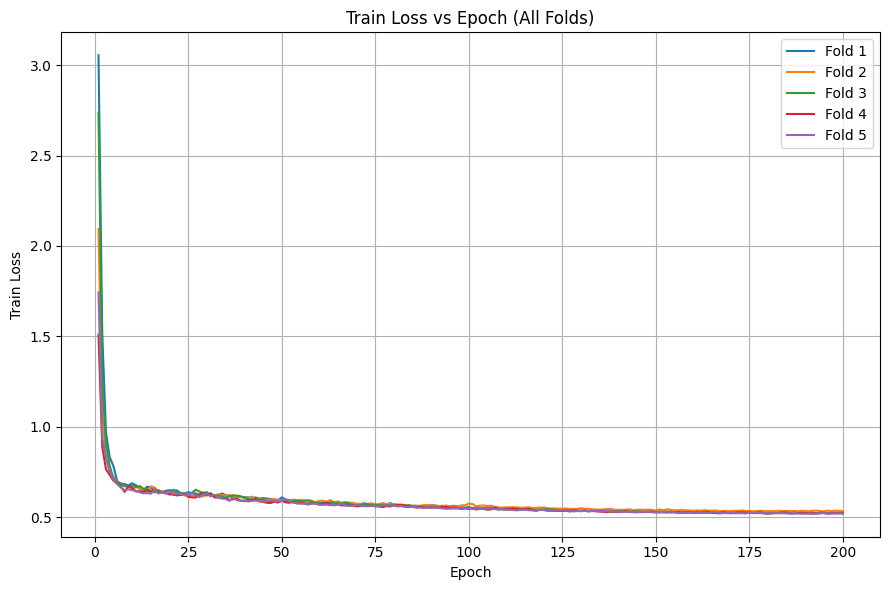

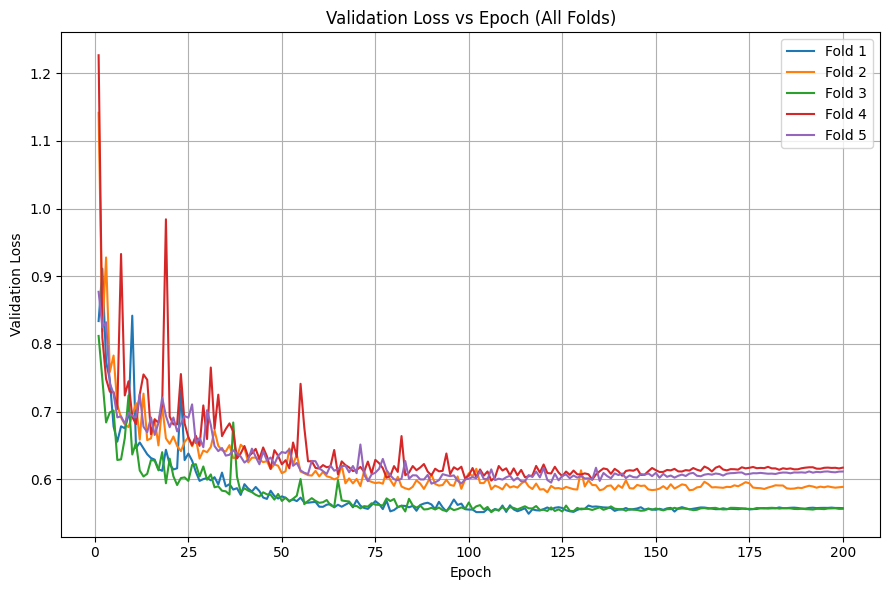

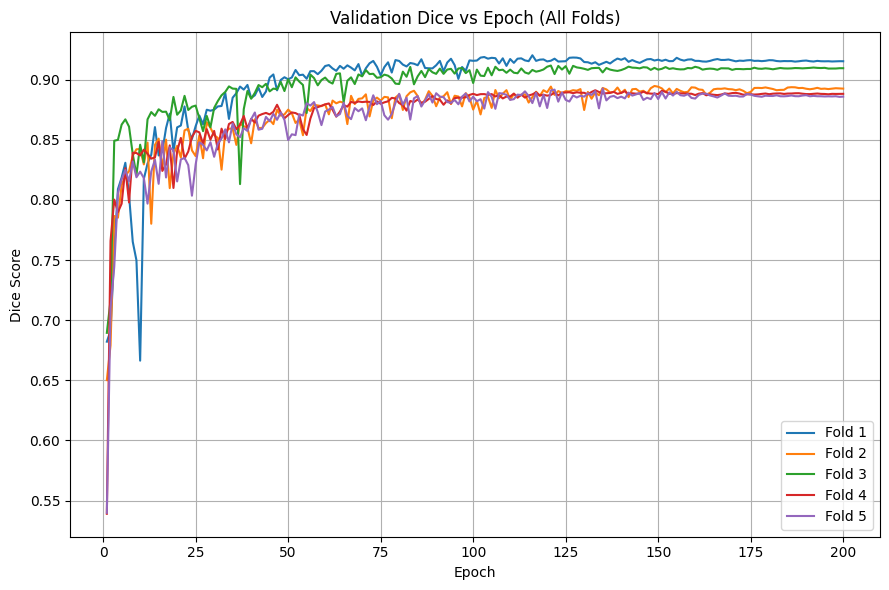

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def plot_train_loss_folds(train_losses_all):
    plt.figure(figsize=(9, 6))

    for i, train_losses in enumerate(train_losses_all):
        epochs = np.arange(1, len(train_losses) + 1)
        plt.plot(epochs, train_losses, label=f'Fold {i+1}')

    plt.xlabel('Epoch')
    plt.ylabel('Train Loss')
    plt.title('Train Loss vs Epoch (All Folds)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def plot_val_loss_folds(val_losses_all):
    plt.figure(figsize=(9, 6))

    for i, val_losses in enumerate(val_losses_all):
        epochs = np.arange(1, len(val_losses) + 1)
        plt.plot(epochs, val_losses, label=f'Fold {i+1}')

    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss vs Epoch (All Folds)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def plot_val_dice_folds(val_dices_all):
    plt.figure(figsize=(9, 6))

    for i, val_dices in enumerate(val_dices_all):
        epochs = np.arange(1, len(val_dices) + 1)
        plt.plot(epochs, val_dices, label=f'Fold {i+1}')

    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.title('Validation Dice vs Epoch (All Folds)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_train_loss_folds(train_losses_all)
plot_val_loss_folds(val_losses_all)
plot_val_dice_folds(val_dices_all)

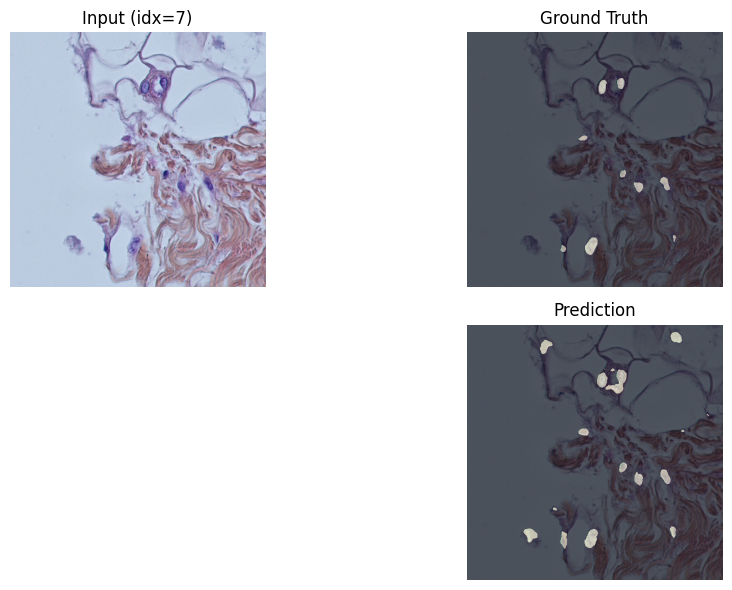

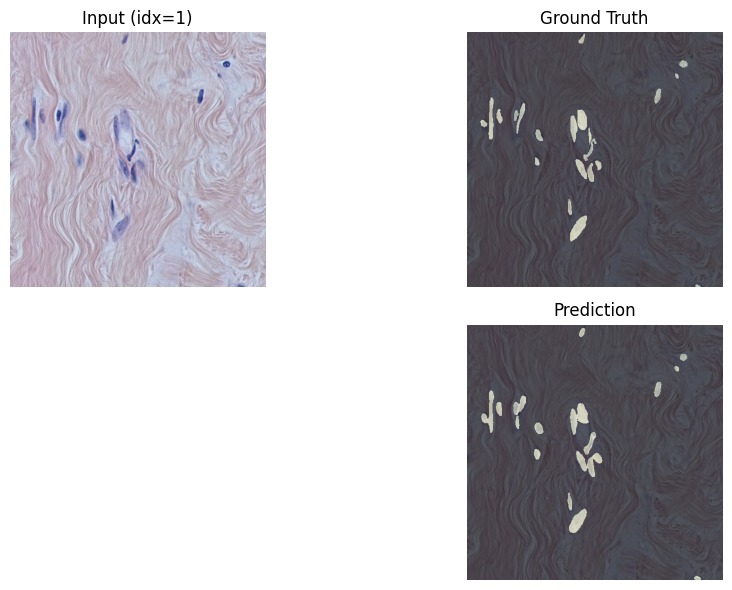

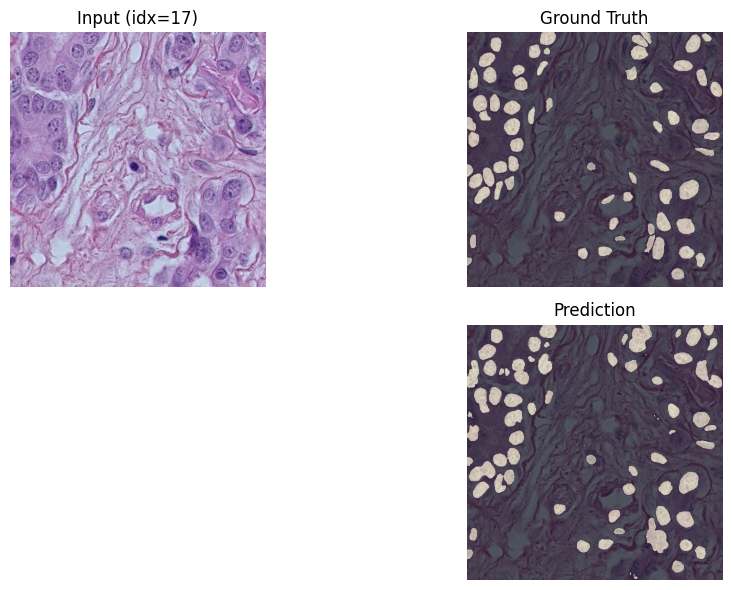

In [14]:
import random
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F


def sample_indices(dataset, num_samples=3, seed=None):
    if seed is not None:
        random.seed(seed)
    return random.sample(range(len(dataset)), num_samples)


def pad_to_multiple(x, multiple):
    _, _, h, w = x.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
    return x, h, w
    

def visualize_random_train_samples(model, dataset, device, indices, downsample_factor=32):
    model.eval()

    with torch.no_grad():
        for idx in indices:
            x, y = dataset[idx]

            x_in = x.unsqueeze(0).to(device)
            x_pad, h, w = pad_to_multiple(x_in, downsample_factor)

            logits = model(x_pad)
            pred = torch.argmax(logits, dim=1)
            pred = pred[:, :h, :w].squeeze().cpu()

            img = x.permute(1, 2, 0).cpu()
            img = (img - img.min()) / (img.max() - img.min())
            gt = y.cpu()

            plt.figure(figsize=(10, 6))

            plt.subplot(2, 2, 1)
            plt.imshow(img)
            plt.title(f"Input (idx={idx})")
            plt.axis("off")

            plt.subplot(2, 2, 2)
            plt.imshow(img)
            plt.imshow(gt, alpha=0.6, cmap="magma")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(2, 2, 4)
            plt.imshow(img)
            plt.imshow(pred, alpha=0.6, cmap="magma")
            plt.title("Prediction")
            plt.axis("off")

            plt.tight_layout()
            plt.show()


indices = sample_indices(cv_subset, num_samples=3, seed=42)
visualize_random_train_samples(model, cv_subset, device, indices)